In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point


In [48]:
df = pd.read_csv("../data/raw/bronx_collisions_raw.csv")


In [49]:
df.info

<bound method DataFrame.info of         collision_id               crash_date crash_time  \
0              72589  2012-07-01T00:00:00.000      20:30   
1              72590  2012-07-01T00:00:00.000      18:40   
2              72591  2012-07-01T00:00:00.000      19:35   
3              72593  2012-07-02T00:00:00.000      11:10   
4              72595  2012-07-02T00:00:00.000      17:30   
...              ...                      ...        ...   
234083       4905761  2026-06-09T00:00:00.000      11:20   
234084       4905762  2026-06-07T00:00:00.000       1:00   
234085       4905763  2026-06-05T00:00:00.000      19:55   
234086       4905769  2026-06-09T00:00:00.000      18:25   
234087       4905770  2026-06-10T00:00:00.000      12:32   

                          on_street_name      cross_street_name   latitude  \
0       CAULDWELL AVENUE                                    NaN  40.821167   
1       WILLOW AVENUE                                       NaN  40.801665   
2       EAST 

In [50]:
print('----------------------------------------------')

print(df.isnull().sum())
print('----------------------------------------------')
print(df.isnull().mean() * 100)
print('----------------------------------------------')
print(df.describe())
print('----------------------------------------------')

----------------------------------------------
collision_id                          0
crash_date                            0
crash_time                            0
on_street_name                    64742
cross_street_name                169736
latitude                           6969
longitude                          6969
number_of_persons_injured             1
number_of_persons_killed           1078
contributing_factor_vehicle_1      1221
dtype: int64
----------------------------------------------
collision_id                      0.000000
crash_date                        0.000000
crash_time                        0.000000
on_street_name                   27.657120
cross_street_name                72.509484
latitude                          2.977086
longitude                         2.977086
number_of_persons_injured         0.000427
number_of_persons_killed          0.460511
contributing_factor_vehicle_1     0.521599
dtype: float64
----------------------------------------------
 

In [51]:
df[['on_street_name','cross_street_name']].isnull().all(axis=1).sum()

np.int64(394)

In [52]:
df[df['number_of_persons_injured'] == 31]

,collision_id,crash_date,crash_time,on_street_name,cross_street_name,latitude,longitude,number_of_persons_injured,number_of_persons_killed,contributing_factor_vehicle_1
133063,4025003,2017-10-10T00:00:00.000,17:10,EAST 149 STREET,NaN,NaN,NaN,31.0,0.0,Aggressive Driving/Road Rage


<Axes: xlabel='longitude', ylabel='latitude'>

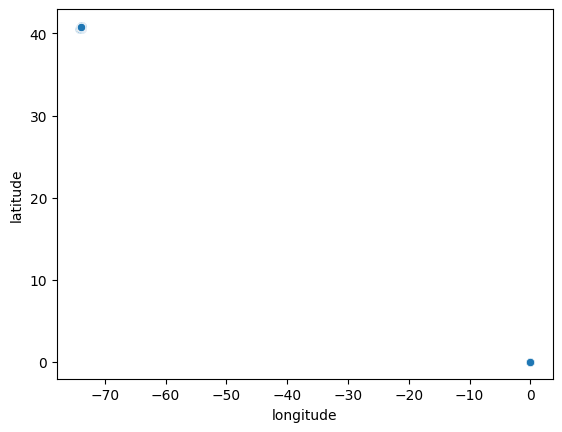

In [53]:
sns.scatterplot(data=df, x='longitude', y='latitude')

In [54]:
(df['longitude'] == 0).sum()

np.int64(1067)

In [55]:
(df['latitude'] == 0).sum()

np.int64(1067)

In [56]:
df_clean = (df[(df['longitude'] != 0) & (df['latitude'] != 0)]).dropna(subset=['latitude', 'longitude'])

<Axes: xlabel='longitude', ylabel='latitude'>

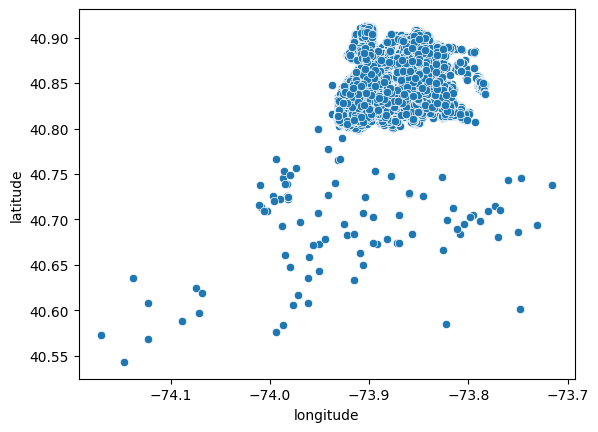

In [57]:
sns.scatterplot(data=df_clean, x='longitude', y='latitude')

In [58]:
boundary_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
boroughs = gpd.read_file(boundary_url)

boroughs.head()

,borocode,boroname,shape_area,shape_leng,geometry
0,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,3,Brooklyn,1934462607.75,726953.04509,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
2,4,Queens,3041419716.32,887902.903727,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."
3,1,Manhattan,636631537.285,359537.906171,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2,Bronx,1187199168.58,463146.326689,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [62]:
bronx = boroughs[boroughs['boroname'] == 'Bronx']
bronx.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [61]:
geometry = [Point(xy) for xy in zip(df_clean['longitude'], df_clean['latitude'])]
df_geo = gpd.GeoDataFrame(df_clean, geometry=geometry, crs="EPSG:4326")
bronx_matched = gpd.sjoin(df_geo, bronx, predicate='within')

In [65]:
print(len(bronx_matched))
print(len(df_clean))

225012
226052


<Axes: xlabel='longitude', ylabel='latitude'>

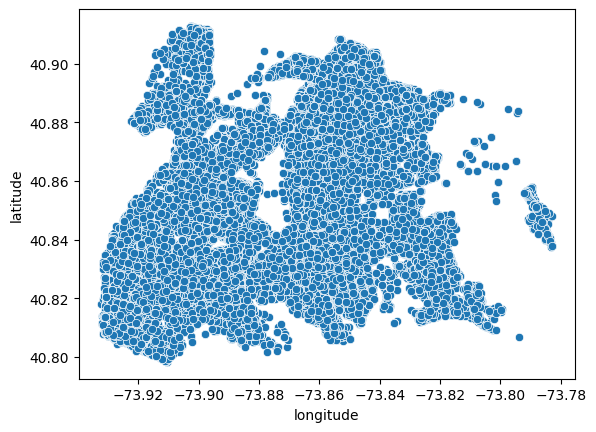

In [67]:
sns.scatterplot(data=bronx_matched, x='longitude', y='latitude')